# Objectifs d'apprentissage (Learning Outcomes)

À l'issue de cette semaine, l'étudiant sera capable de :

- **Définir** le Traitement Numérique du Signal (**Digital Signal Processing**) et expliquer ses avantages par rapport au traitement analogique (flexibilité, reproductibilité, stockage, intelligence embarquée).

- **Décrire** la chaîne de traitement complète (Anti-alias → CAN(ADC) → Processeur → CNA(DAC) → Lissage).

- **Classifier** un signal selon ses propriétés fondamentales (continu/discret, analogique/numérique, périodique/apériodique, causal/non-causal, pair/impair, énergie/puissance).

- **Identifier** des applications concrètes du DSP dans des secteurs variés (audio, télécoms, biomédical, automobile, spatial).

- **Visualiser** un signal sinusoïdal, son échantillonnage et le phénomène de repliement (aliasing) via un code Python.

- **Différencier** entre différentes architecture de circuits DSP (Disgital Signal Processors)


# 1.Introduction générale

 ## 1.1 Définition: 

 Le traitement du signal (Signal Processing)  est l'ensemble des techniques mathématiques et technologiques visant à analyser, modifier, synthétiser ou interpréter des signaux porteurs d’information.
 
 Ces signaux peuvent être d’origine physique (température, pression, son, image, tension électrique, etc.) et sont généralement convertis en grandeurs électriques pour être traités.

On distingue deux grandes familles :

Le traitement analogique : il agit directement sur le signal électrique continu à l’aide de composants électroniques passifs et actifs (résistances, condensateurs, bobines, amplificateurs opérationnels).

Le traitement numérique (Digital Signal Processing) : il opère sur une représentation binaire (suite de 0 et de 1) du signal, obtenue après échantillonnage et quantification. Le traitement est réalisé par des algorithmes exécutés sur des processeurs spécialisés (DSP, ARM, FPGA) ou des ordinateurs.

---

## 1.2 Différences fondamentales : traitement analogique vs numérique.

Le tableau ci-dessous résume les disparités essentielles entre ces deux approches :

| Critère | Traitement analogique | Traitement numérique |
| :--- | :--- | :--- |
| **Nature du signal** | Signal continu dans le **temps** et en **amplitude**. | Signal **discret** dans le temps (échantillons) et en amplitude (quantifié sur $N$ bits). |
| **Composants de base** | Résistances, condensateurs, bobines, amplificateurs opérationnels (AO), transistors. | Portes logiques, additeurs, multiplieurs, bascules, mémoires (et unités de calcul). |
| **Opérations élémentaires** | Intégration, dérivation, filtrage par fonction de transfert (réponse fréquentielle). | Additions, multiplications, décalages binaires (algorithmes récursifs ou non-récursifs). |
| **Précision / Tolérance** | Limitée par la tolérance des composants ($\pm 5\%$, $\pm 1\%$), la dérive thermique et le vieillissement. | Déterminée par le nombre de bits de quantification (ex: 16 bits $\to$ précision de $1/65536$) ; rigoureusement reproductible. |
| **Sensibilité au bruit** | Le bruit s'**accumule** le long de la chaîne (chaque étage ajoute sa propre distorsion). | Forte **immunité au bruit** (tant que le bruit n'altère pas la discrimination entre niveaux logiques 0 et 1). |
| **Modification / Réglage** | Nécessite de modifier physiquement les composants (changer une résistance, un condensateur) ou de concevoir un nouveau circuit imprimé. | Simple changement du **logiciel** ou du firmware (reprogrammation). |
| **Stockage et relecture** | Difficile, nécessite des enregistreurs analogiques (bandes magnétiques) et se dégrade dans le temps. | Stockage aisé et parfait (copies identiques) sur mémoires numériques (RAM, disque dur, cloud). |
| **Traitements complexes** | Très limité pour les algorithmes complexes (FFT, filtres adaptatifs, IA) ; devient vite irréaliste. | Permet des algorithmes très sophistiqués sans coût matériel supplémentaire (uniquement par le code). |

---

## 1.3 Avantages clés du traitement numérique

Le traitement numérique s’est imposé dans la quasi-totalité des domaines (télécommunications, audio, biomédical, automobile, aérospatial) pour les raisons fondamentales suivantes :

- **✅ Flexibilité**  
  - Un même dispositif matériel (ex: un DSP) peut assurer des fonctions radicalement différentes en ne changeant que le programme.  
  - On peut adapter le traitement en temps réel (filtrage adaptatif, annulation d'écho, correction dynamique) sans toucher à l'électronique.  
  - Possibilité d'implémenter des fonctions non-linéaires ou temporelles qui seraient très complexes en analogique.

- **✅ Reproductibilité**  
  - Deux systèmes numériques identiques produisent **strictement les mêmes résultats** dans les mêmes conditions d'entrée (pas de dispersion due aux tolérances de fabrication).  
  - Les performances ne se dégradent pas avec le temps (pas de vieillissement des composants passifs) ni avec les variations de température (contrairement aux AO et aux condensateurs).

- **✅ Précision**  
  - La précision est uniquement limitée par le **nombre de bits** du convertisseur (CAN/CNA) et la largeur des registres internes (virgule fixe ou flottante).  
  - On peut atteindre une précision relative de l'ordre de $10^{-6}$ (20 bits) voire $10^{-15}$ (double précision 64 bits), ce qui est inatteignable en analogique pur où les distorsions harmoniques et le bruit thermique sont physiquement inévitables.

- **✅ Stockage**  
  - Les signaux numérisés peuvent être **stockés sans perte** sur des supports durables (SSD, cloud, etc.).  
  - On peut ainsi :  
    - Comparer des signaux enregistrés à des moments différents,  
    - Effectuer des traitements **hors-ligne** (post-traitement),  
    - Transmettre les données sans altération sur de longues distances (télécommunications),  
    - Compresser les données pour économiser de la bande passante.

- **✅ Intelligence embarquée (Smart processing)**  
  - Le traitement numérique permet d'intégrer des capacités cognitives avancées directement dans les systèmes (embarqués) :  
    - Réseaux de neurones et **IA** (reconnaissance vocale, visage, classification),  
    - Filtrage optimal (Kalman, particulaire),  
    - Détection de défauts et diagnostics prédictifs,  
    - Traitement adaptatif qui s'ajuste automatiquement à l'environnement (ex: réduction active du bruit, égalisation de canal).  
  - Ces fonctionnalités, impossibles ou très coûteuses en analogique, deviennent accessibles grâce à la puissance de calcul croissante des microcontrôleurs et des FPGA.

# 2. Chaîne de traitement DSP

## 2.1 Schéma bloc

La chaîne de traitement numérique classique se décompose comme suit :


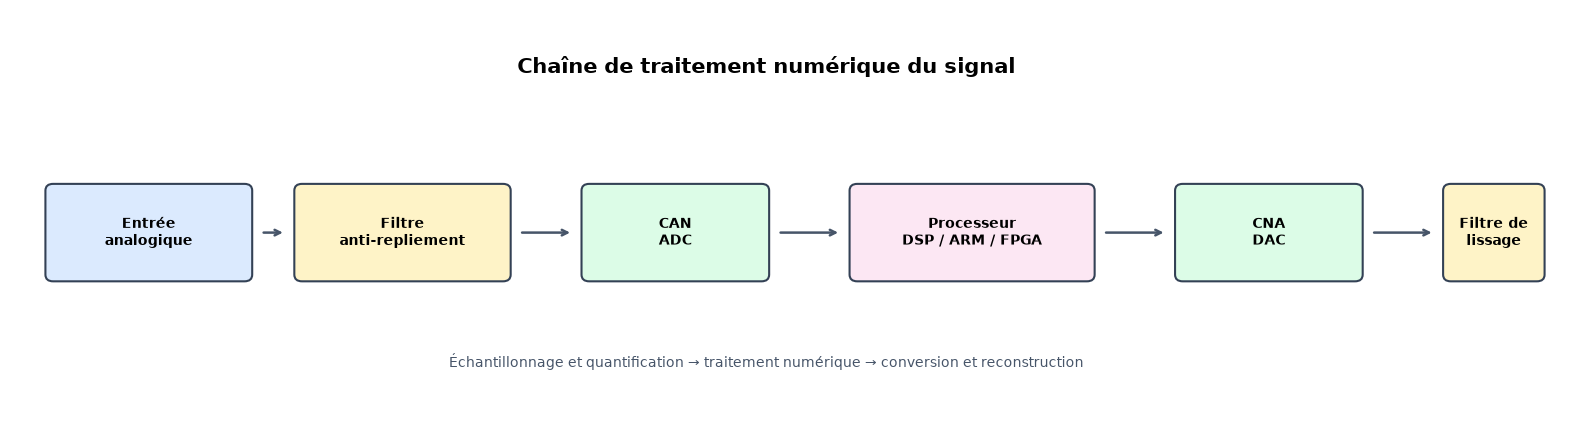

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.set_xlim(0, 16.4)
ax.set_ylim(0, 5)
ax.axis('off')

blocks = [
    (0.4, 1.8, 2.1, 1.1, 'Entrée\nanalogique', '#dbeafe'),
    (3.0, 1.8, 2.2, 1.1, 'Filtre\nanti-repliement', '#fef3c7'),
    (6.0, 1.8, 1.9, 1.1, 'CAN\nADC', '#dcfce7'),
    (8.8, 1.8, 2.5, 1.1, 'Processeur\nDSP / ARM / FPGA', '#fce7f3'),
    (12.2, 1.8, 1.9, 1.1, 'CNA\nDAC', '#dcfce7'),
    (15.0, 1.8, 1.0, 1.1, 'Filtre de\nlissage', '#fef3c7'),
]

for x, y, width, height, label, color in blocks:
    patch = FancyBboxPatch(
        (x, y), width, height,
        boxstyle='round,pad=0.03,rounding_size=0.08',
        facecolor=color, edgecolor='#334155', linewidth=1.5,
    )
    ax.add_patch(patch)
    ax.text(x + width / 2, y + height / 2, label, ha='center', va='center', fontsize=10, weight='bold')

for index in range(len(blocks) - 1):
    x, y, width, height, *_ = blocks[index]
    next_x = blocks[index + 1][0]
    ax.annotate(
        '', xy=(next_x - 0.12, y + height / 2), xytext=(x + width + 0.12, y + height / 2),
        arrowprops={'arrowstyle': '->', 'color': '#475569', 'linewidth': 1.8},
    )

ax.text(7.9, 4.25, 'Chaîne de traitement numérique du signal', ha='center', fontsize=15, weight='bold')
ax.text(7.9, 0.75, 'Échantillonnage et quantification → traitement numérique → conversion et reconstruction', ha='center', fontsize=10, color='#475569')
plt.tight_layout()
plt.show()

## Explication du rôle de chaque bloc de la chaîne de traitement DSP

---

### 2.1. Filtre anti-repliement (Anti-Aliasing Filter)

- **Nature** : Filtre analogique passe‑bas.
- **Rôle** :
  - Limiter la bande passante du signal d'entrée à une valeur inférieure à la **moitié de la fréquence d'échantillonnage** ($f_e/2$), conformément au critère de Nyquist-Shannon.
  - Supprimer les composantes fréquentielles supérieures à $f_e/2$ qui, après échantillonnage, viendraient se **replier** (aliasing) dans la bande utile et dégraderaient irrémédiablement le signal.
- **Conséquence** : C'est un filtre *indispensable* avant tout échantillonnage. Sans lui, il est impossible de reconstruire fidèlement le signal original.

---

### 2.2. CAN – Convertisseur Analogique‑Numérique (ADC)

Le CAN réalise deux opérations distinctes et successives :

- **a) Échantillonnage (Sampling)**
  - Prélèvement du signal analogique à des instants réguliers, espacés d'une période $T_e = 1/f_e$.
  - Le signal devient **discret dans le temps** (suite d'échantillons), mais les amplitudes restent continues (valeurs réelles).

- **b) Quantification (Quantization)**
  - Arrondi (ou troncature) de chaque échantillon à la valeur la plus proche parmi un ensemble fini de niveaux prédéfinis (codage sur $N$ bits → $2^N$ niveaux).
  - Le signal devient **discret en amplitude** (numérique).
  - Introduction d'une **erreur de quantification** (bruit de quantification) dont la puissance diminue lorsque le nombre de bits $N$ augmente.

- **Rôle global du CAN** : Transformer un signal analogique (continu en temps et en amplitude) en une suite de mots binaires (signal numérique) exploitable par un processeur.

---

### 2.3. Processeur numérique (DSP / ARM / FPGA)

- **Nature** : Unité de calcul programmable. Il peut s'agir d'un processeur spécialisé (DSP), d'un microcontrôleur (ARM), ou d'un circuit logique reconfigurable (FPGA).
- **Rôle** :
  - Exécute les algorithmes de traitement numérique pour lesquels la chaîne a été conçue :
    - Filtrage numérique (FIR, IIR),
    - Transformées (FFT, DCT, ondelettes),
    - Modulation / démodulation,
    - Contrôle‑commande (PID, correcteurs numériques),
    - Compression de données,
    - Détection de motifs, réseaux de neurones, etc.
  - Il agit sur les **échantillons numériques** (valeurs binaires en entrée) et produit une nouvelle séquence numérique en sortie, selon les calculs programmés.

---

### 2.4. CNA – Convertisseur Numérique‑Analogique (DAC)

- **Rôle** :
  - Reconvertir la séquence numérique issue du processeur en un signal analogique (continu en temps et en amplitude).
  - En pratique, le CNA maintient chaque valeur de sortie constante entre deux instants d'échantillonnage : on obtient un signal en **escalier** (blocage d'ordre zéro).
- **Conséquence fréquentielle** : Ce signal en escalier contient, en plus du signal original, des **répliques spectrales** (images) du spectre à des multiples de $f_e$. Ces répliques doivent être éliminées par l'étage suivant.

---

### 2.5. Filtre de lissage (Filtre de restitution / Reconstruction)

- **Nature** : Filtre analogique passe‑bas.
- **Rôle** :
  - Lisser le signal en escalier provenant du CNA pour obtenir un signal analogique continu et fluide.
  - Atténuer les répliques spectrales hautes fréquences (multiples de $f_e$) générées par le blocage du CNA.
  - Ne conserver que la bande de base (le spectre original) pour restituer un signal analogique aussi proche que possible du signal d'entrée (aux erreurs de quantification et de traitement près).
- **Remarque** : Idéalement, ce filtre a une fréquence de coupure proche de $f_e/2$, comme le filtre anti‑repliement, mais il travaille en sortie de la chaîne.

# 3. Classification des signaux
- Temps continu vs Temps discret.
- Amplitude continue (analogique) vs Amplitude discrète (numérique).
- Périodique vs Apériodique.
- Déterministe vs Aléatoire (stochastique).
- Signaux à énergie finie vs Signaux à puissance moyenne finie.
- Causal vs Non-causal.
- Pair vs Impair.

# 3. Classification des signaux

La classification des signaux est une étape fondamentale en traitement du signal. Elle permet de choisir les outils mathématiques et les techniques de traitement adaptés à chaque type de signal. Un même signal physique peut être classé selon plusieurs critères indépendants.

---

## 3.1 Temps continu vs Temps discret

Cette classification concerne la **variable indépendante** (généralement le temps).

| Critère | Signal à temps continu | Signal à temps discret |
| :--- | :--- | :--- |
| **Définition** | La variable $t$ (temps) peut prendre **toutes les valeurs** réelles sur un intervalle continu. | La variable $n$ ne prend que des **valeurs entières** (instants échantillonnés). |
| **Notation** | $x(t)$ | $x[n]$ |
| **Représentation** | Fonction mathématique continue. | Suite de nombres (échantillons). |
| **Exemple** | $x(t) = \cos(2\pi \times 1000t)$<br>$x(t) = e^{-2\|t\|}$ | $x[n] = (0.5)^n u[n]$<br>$x[n] = \sin(\pi n / 4)$ |

---

## 3.2 Amplitude continue (analogique) vs Amplitude discrète (numérique)

Cette classification concerne la **variable dépendante** (l'amplitude du signal).

| Critère | Signal analogique (à amplitude continue) | Signal numérique (à amplitude discrète) |
| :--- | :--- | :--- |
| **Définition** | L'amplitude peut prendre **n'importe quelle valeur** réelle dans un intervalle. | L'amplitude ne peut prendre qu'un **ensemble fini de valeurs** (niveaux de quantification). |
| **Relation avec le temps** | Peut être continu ou discret dans le temps. | Est toujours discret dans le temps. |
| **Exemple** | Un signal audio avant numérisation.<br>$x(t) = t^2$ (pour $t \ge 0$). | La sortie d'un CAN (ex: valeurs codées sur 8 bits, soit 256 niveaux). |
| **Remarque** | On parle souvent de signal **analogique** pour un signal continu en temps ET en amplitude. | On parle de signal **numérique** pour un signal discret en temps ET en amplitude. |

---

## 3.3 Périodique vs Apériodique

Cette classification concerne la **répétition temporelle** du signal.

| Critère | Signal périodique | Signal apériodique (non périodique) |
| :--- | :--- | :--- |
| **Définition (temps continu)** | Il existe une constante $T > 0$ (la période) telle que : <br> $$ x(t + T) = x(t) \quad \forall t $$ | Aucune valeur $T \neq 0$ ne satisfait la condition de périodicité. |
| **Définition (temps discret)** | Il existe un entier $N > 0$ (la période) tel que : <br> $$ x[n + N] = x[n] \quad \forall n $$ | La condition n'est vérifiée pour aucun entier $N \neq 0$. |
| **Période fondamentale** | La plus petite valeur positive de $T$ (ou $N$) vérifiant la condition. | Non définie. |
| **Exemple** | $x(t) = \cos(2\pi t)$ est périodique de période $T = 1$ s. <br> $x[n] = \sin(\pi n/4)$ est périodique de période $N = 8$ échantillons. | $x(t) = e^{-2\|t\|}$ n'est pas périodique (décroît exponentiellement).<br>$x[n] = (0.5)^n u[n]$ tend vers 0 et n'est pas périodique. |

> ⚠️ **Attention** : En temps discret, la période $N$ doit être un nombre **entier**. Un signal comme $\sin(0.5 n)$ n'est pas périodique car $2\pi / 0.5 = 4\pi$ n'est pas un nombre rationnel.

---

## 3.4 Déterministe vs Aléatoire (stochastique)

Cette classification concerne la **prévisibilité** du signal.

| Critère | Signal déterministe | Signal aléatoire (stochastique) |
| :--- | :--- | :--- |
| **Définition** | Le signal peut être décrit par une **expression mathématique explicite** ou un algorithme connu. Sa valeur future est parfaitement connue à tout instant. | Le signal suit des **lois de probabilité**. On ne peut pas prédire sa valeur exacte future, seulement des propriétés statistiques (moyenne, variance, densité spectrale). |
| **Représentation** | Fonction mathématique unique. | Ensemble de réalisations (processus stochastique). |
| **Exemple** | $x(t) = \cos(2\pi \times 1000t) + \cos(2\pi \times 2000t)$ <br> $x[n] = (0.5)^n u[n]$ | Le bruit de quantification, le bruit thermique dans un circuit, le signal de parole (même si on connaît la phrase, la forme d'onde exacte dépend du locuteur). |
| **Outils d'analyse** | Transformées de Fourier, équations différentielles. | Statistiques, corrélation, densité spectrale de puissance. |

---

## 3.5 Signaux à énergie finie vs Signaux à puissance moyenne finie

Cette classification concerne la **quantité d'énergie** ou la **puissance moyenne** du signal.

- **Énergie totale** $E$ (pour un signal réel) :

  $$ \text{Temps continu : } E = \int_{-\infty}^{+\infty} |x(t)|^2 dt $$

  $$ \text{Temps discret : } E = \sum_{n=-\infty}^{+\infty} |x[n]|^2 $$

- **Puissance moyenne** $P$ (pour un signal réel) :

  $$ \text{Temps continu : } P = \lim_{T \to \infty} \frac{1}{2T} \int_{-T}^{T} |x(t)|^2 dt $$

  $$ \text{Temps discret : } P = \lim_{N \to \infty} \frac{1}{2N+1} \sum_{n=-N}^{N} |x[n]|^2 $$

| Critère | Signal à énergie finie | Signal à puissance moyenne finie |
| :--- | :--- | :--- |
| **Condition** | $0 < E < +\infty$ (énergie finie) et **$P = 0$**. | $0 < P < +\infty$ (puissance moyenne finie) et **$E \to \infty$**. |
| **Typicité** | Signaux **transitoires** (impulsions, exponentielles décroissantes). | Signaux **permanents** ou périodiques (sinusoïdes, bruit stationnaire). |
| **Exemple (énergie)** | $x(t) = e^{-2\|t\|}$ (l'intégrale du carré converge). <br> $x[n] = (0.5)^n u[n]$ (la somme converge). | $x(t) = \cos(2\pi \times 1000t)$ (l'énergie sur l'infini diverge, mais la puissance moyenne est finie : $P = 1/2$). |
| **Remarque** | Un signal ne peut pas être à la fois à énergie finie ET à puissance finie non nulle (sauf le signal nul). |

---

## 3.6 Causal vs Non-causal

Cette classification concerne la **dépendance temporelle** du signal par rapport à l'origine des temps ($t=0$ ou $n=0$).

| Critère | Signal causal | Signal non-causal | Signal anti-causal |
| :--- | :--- | :--- | :--- |
| **Définition** | Le signal est **nul** pour tout $t < 0$ (ou $n < 0$). <br> Il ne dépend que du passé et du présent. | Le signal n'est **pas nul** pour certaines valeurs $t < 0$ (ou $n < 0$). Il dépend du futur. | Le signal est **nul** pour tout $t > 0$ (ou $n > 0$). Il ne dépend que du passé (rarement utilisé seul). |
| **Exemple** | $x(t) = \begin{cases} t^2, & t \ge 0 \\ 0, & t < 0 \end{cases}$ <br> $x[n] = (0.5)^n u[n]$ | $x(t) = \cos(2\pi \times 1000t)$ (existe pour $t<0$). <br> $x(t) = e^{-2|t|}$ (existe pour $t<0$). | $x(t) = e^{2t} u(-t)$ (existe uniquement pour $t<0$). |
| **Remarque** | En traitement du signal **temps réel**, tous les signaux traités sont nécessairement causals (on ne peut pas lire le futur). En traitement **hors ligne** (post-traitement), on peut manipuler des signaux non-causals. |

---

## 3.7 Pair vs Impair

Cette classification concerne la **symétrie** du signal par rapport à l'origine (réflexion temporelle).

| Critère | Signal pair (symétrique) | Signal impair (antisymétrique) |
| :--- | :--- | :--- |
| **Définition (temps continu)** | $x(-t) = x(t)$ | $x(-t) = -x(t)$ |
| **Définition (temps discret)** | $x[-n] = x[n]$ | $x[-n] = -x[n]$ |
| **Propriété centrale** | Symétrie par rapport à l'axe vertical (partie réelle uniquement). | Symétrie par rapport à l'origine (partie réelle uniquement). |
| **Valeur à l'origine** | $x(0)$ peut être n'importe quelle valeur. | Impose $x(0) = 0$ (en $t=0$) et $x[0] = 0$. |
| **Exemple** | $x(t) = \cos(2\pi \times 1000t)$ <br> $x(t) = e^{-2|t|}$ (valeur absolue). | $x(t) = \sin(2\pi \times 1000t)$ <br> $x[n] = \sin(\pi n / 4)$ |
| **Remarque** | **Tout signal** $x(t)$ peut se décomposer en une somme d'un signal pair $x_p(t)$ et d'un signal impair $x_i(t)$ : <br> $x_p(t) = \frac{x(t) + x(-t)}{2}$ <br> $x_i(t) = \frac{x(t) - x(-t)}{2}$ | Cette décomposition est très utilisée en traitement du signal pour simplifier les calculs de transformées de Fourier (la transformée d'un signal pair est réelle, celle d'un signal impair est imaginaire pure). |

# 4. Applications du DSP
- **Audio** : casques anti-bruit, compression MP3, égaliseurs.
- **Télécoms** : 4G/5G, modulation/démodulation, égalisation.
- **Biomédical** : ECG, EEG, filtrage des artéfacts, prothèses auditives.
- **Automobile** : détection des cliquetis moteur, contrôle actif du bruit.
- **Défense & Spatial** : Radar, Sonar, imagerie satellite.
- **IoT/Embarqué** : assistants vocaux, capteurs intelligents.

# 4. Applications du Traitement Numérique du Signal (DSP)

Le DSP est omniprésent dans notre quotidien, des smartphones aux voitures électriques, en passant par l'imagerie médicale. Il permet de **transformer, analyser ou interpréter** des signaux pour en extraire l'information utile tout en rejetant les parasites. 

Voici un panorama des principaux secteurs où le DSP joue un rôle critique, avec pour chacun les algorithmes et concepts enseignés dans ce cours.

---

## Audio et Acoustique

| Sous-domaine | Problème physique | Techniques DSP utilisées |
| :--- | :--- | :--- |
| **Casques anti-bruit (ANC)** | Annuler les bruits ambiants (moteur d'avion, ventilateur) en générant une onde sonore opposée (interférence destructive). | **Filtres adaptatifs (RIF/RII)** pour estimer la réponse acoustique, **retard pur** (Delay) et **annulation de phase**. L'algorithme doit fonctionner en temps réel avec une latence < 100 µs. |
| **Compression audio (MP3 / AAC)** | Réduire la taille des fichiers musicaux (de 50 Mo à 5 Mo) sans perte audible de qualité. | **Transformée en Cosinus Discret Modifiée (MDCT)** pour l'analyse spectrale, **seuillage psychoacoustique** (modélisation du masque fréquentiel de l'oreille humaine) et **quantification adaptative**. |
| **Égaliseurs (EQ)** | Ajuster les niveaux de fréquences (graves, médiums, aigus) pour corriger la réponse d'une enceinte ou adapter le son aux goûts de l'auditeur. | **Filtres RII / RIF** en cascade (passe-bas, passe-haut, passe-bande). L'égaliseur graphique est une somme de filtres en peigne paramétriques. |

> 🎯 **Lien avec le cours** : L'ANC fait appel au **filtrage adaptatif** (extension des chapitres 5 & 7). La compression MP3 repose sur la **DCT** (Chapitre 8, section 8.8). Les égaliseurs mettent en œuvre la **conception de filtres** (Chapitre 7).

---

## Télécommunications

| Sous-domaine | Problème physique | Techniques DSP utilisées |
| :--- | :--- | :--- |
| **4G / 5G** | Transmettre des données (voix, vidéo, internet) à très haut débit via des ondes radio, malgré les interférences et la mobilité des utilisateurs. | **Modulation OFDM** (qui utilise la FFT pour multiplexer de nombreuses sous-porteuses), **filtres de mise en forme d'impulsion** (Nyquist), et **correction d'erreurs** (FEC). |
| **Égalisation** | Compenser les distorsions du canal de transmission (échos, trajets multiples, trajets multiples). Le signal reçu est la somme de plusieurs copies décalées dans le temps. | **Filtres RII/RIF adaptatifs** (ex: égaliseur à décision dirigée) qui "déconvoluent" le canal en estimant sa réponse impulsionnelle inverse. |
| **Modulation/Démodulation** | Transposer le signal numérique en bande de base vers une fréquence porteuse (et inversement) pour l'émission/réception radio. | **Multiplication par une exponentielle complexe** (mélangeur numérique), **filtrage passe-bande** et **traitement en bande de base** (IQ demodulation). |

> 🎯 **Lien avec le cours** : L'OFDM utilise la **FFT** (Chapitre 9). L'égalisation repose sur les **systèmes LTI et la transformée en Z** (Chapitres 2, 3 et 5). Les modulateurs utilisent la **formule d'Euler** (Chapitre 2).

---

## Biomédical et Santé

| Sous-domaine | Problème physique | Techniques DSP utilisées |
| :--- | :--- | :--- |
| **ECG (Électrocardiogramme)** | Mesurer l'activité électrique du cœur pour détecter des arythmies ou des infarctus. Le signal (quelques millivolts) est noyé dans le bruit (muscles, 50/60 Hz du secteur). | **Filtrage RIF/RII** (passe-bande 0.5–100 Hz), **filtre coupe-bande** (notch filter à 50 Hz), **détection d'ondes QRS** (par analyse en ondelettes ou par seuillage après filtrage). |
| **EEG (Électroencéphalogramme)** | Mesurer l'activité cérébrale (ondes alpha, bêta, etc.) via des électrodes sur le crâne. Le signal est extrêmement faible (µV) et corrompu par les artefacts (clignements d'yeux, mouvements). | **Filtrage spatial** (séparation de sources via ICA), **analyse spectrale (FFT)** pour identifier les bandes de fréquences (delta, thêta, alpha, bêta), **filtrage adaptatif** pour rejeter les artéfacts. |
| **Prothèses auditives** | Amplifier sélectivement les sons utiles (parole) tout en atténuant le bruit de fond, en temps réel et avec une très faible consommation d'énergie. | **Filtrage multicanaux** (bank de filtres), **compression de dynamique**, **réduction de bruit** (soustraction spectrale), **filtrage adaptatif** pour lutter contre le feedback (Larsen). |

> 🎯 **Lien avec le cours** : Le filtrage ECG est un cas d'école des **filtres RII/RIF** (Chapitres 5 et 7). L'analyse EEG utilise la **FFT et l'analyse spectrale** (Chapitres 8, 9 et 10). 

---

## Automobile

| Sous-domaine | Problème physique | Techniques DSP utilisées |
| :--- | :--- | :--- |
| **Détection des cliquetis moteur** | Détecter les micro-explosions anormales (cliquetis) dans le moteur thermique pour ajuster l'avance à l'allumage et éviter la casse. Le signal est acoustique (vibrations). | **Analyse spectrale (FFT)** sur des fenêtres de temps courtes, **détection d'énergie** dans une bande de fréquence spécifique (5–15 kHz), **filtrage passe-bande**. |
| **Contrôle actif du bruit** | Annuler le bruit du moteur ou du roulement dans l'habitacle, en utilisant des haut-parleurs du système audio. | **Filtrage adaptatif (FXLMS)** , **annulation de phase**, mêmes principes que les casques ANC, mais avec des microphones et haut-parleurs déportés. |
| **Radar de recul / LiDAR** | Mesurer la distance et la vitesse des obstacles (piétons, voitures) à l'aide d'ondes ultrasonores ou laser. | **Génération de chirps** (sinusoïdes à fréquence variable), **corrélation** (pour estimer le temps de vol), **FFT** pour extraire la vitesse par effet Doppler, **filtrage de Kalman** pour le suivi. |

> 🎯 **Lien avec le cours** : La détection de cliquetis est une application directe de **l'analyse de Fourier** (Chapitre 10). Le radar de recul utilise la **convolution/corrélation** (Chapitre 2) et la **FFT** (Chapitre 9).

---

## Industrie, Robotique et Véhicules Électriques (Control Moteur)

| Sous-domaine | Problème physique | Techniques DSP utilisées |
| :--- | :--- | :--- |
| **Commande de moteurs électriques (Motor Control)** | Piloter avec une extrême précision la vitesse, le couple et la position d'un moteur synchrone à aimants permanents (PMSM) ou d'un moteur sans balais (BLDC) dans des environnements contraints : voitures électriques (Tesla, Renault), drones, robots industriels, servomoteurs de précision. Les signaux traités sont les **courants et tensions triphasés** (noyés dans le bruit de commutation PWM) et les **signaux de position** (encodeur, capteur Hall, ou estimation sans capteur). | • **Transformées de Clarke et Park** : Passage du repère triphasé (a,b,c) à un repère biphasé fixe (α,β), puis à un repère tournant (d,q) synchrone avec le rotor. Cette transformation (qui utilise des **exponentielles complexes** \( e^{j\theta} \)) convertit des courants alternatifs sinusoïdaux en grandeurs continues (courant direct \( I_d \) et courant en quadrature \( I_q \)), ce qui simplifie la régulation (on pilote le moteur comme un moteur à courant continu). <br><br> • **Filtrage numérique RIF/RII** : Lissage des mesures de courant pour éliminer les harmoniques haute fréquence issues de la commutation des transistors de puissance. Sans ce filtrage, les boucles de régulation deviennent instables (oscillations). <br><br> • **Filtrage de Kalman** (ou observateurs d'état) : Estimation en temps réel de la vitesse et de la position du rotor **sans capteur mécanique** (sensorless), en fusionnant les mesures de courant, de tension et les modèles électriques du moteur. Cette technique réduit les coûts et améliore la fiabilité. <br><br> • **FFT / Analyse spectrale** : Surveillance vibratoire des moteurs pour la **maintenance prédictive**. L'analyse des harmoniques du courant et des vibrations permet de détecter un défaut de roulement, un déséquilibre rotorique ou une démagnétisation partielle avant la panne. |
| **Systèmes embarqués de puissance (Onduleurs)** | Convertir la batterie (DC) en courant alternatif (AC) pour alimenter le moteur, en générant des signaux de commande (PWM) à très haute fréquence tout en minimisant les pertes et les harmoniques. | • **Génération de PWM (Modulation de Largeur d'Impulsion)** : Synthèse d'une sinusoïde par modulation de densité d'impulsions, basée sur des **comparateurs numériques** et des **tables de sinusoïdes**. <br><br> • **Compensation des temps morts** : Filtrage et correction pour éviter les distorsions dues aux délais de commutation des semi-conducteurs. |

> 🎯 **Lien avec le cours** : 
> - Les **transformées de Clarke/Park** sont une application directe des **combinaisons linéaires** et des **rotations par exponentielle complexe** \( e^{j\theta} \) (Chapitres 2, formule d'Euler, et 8 pour la périodicité spatiale). 
> - Le **filtrage des courants** s'appuie sur les **filtres RIF et RII** (Chapitres 5, 7 et 10). 
> - L'**estimation d'état (Kalman)** dépasse le cadre de ce cours, mais elle repose fondamentalement sur les **systèmes LTI et les équations aux différences** (Chapitre 2). 
> - L'**analyse vibratoire par FFT** est une application classique de l'**analyse spectrale** (Chapitres 8, 9 et 10).

---

## Défense et Spatial

| Sous-domaine | Problème physique | Techniques DSP utilisées |
| :--- | :--- | :--- |
| **Radar / Sonar** | Détecter des cibles (avions, sous-marins) en analysant l'écho d'une onde émise (radio ou acoustique). Le signal reçu est extrêmement faible et noyé dans un bruit intense. | **Filtrage adapté (matched filtering)** = corrélation avec le signal émis, **compression d'impulsions** (via la FFT), **détection CFAR** (seuil adaptatif), **intégration Doppler** (FFT sur les pulses successifs). |
| **Imagerie satellite** | Restaurer et analyser des images issues de satellites (météo, espionnage, agriculture), dégradées par le bruit du capteur, l'atmosphère et le mouvement. | **Filtrage 2D** (médian, passe-bas), **amélioration de contraste** (égalisation d'histogramme), **restauration d'image** (déconvolution), **compression JPEG2000** (wavelets). |

> 🎯 **Lien avec le cours** : Le *matched filtering* est une application directe de la **convolutio**n (Chapitre 2). L'imagerie étend le DSP à **deux dimensions**, mais les concepts (filtrage, transformées) restent les mêmes.

---

## IoT et Embarqué

| Sous-domaine | Problème physique | Techniques DSP utilisées |
| :--- | :--- | :--- |
| **Assistants vocaux (Alexa, Siri)** | Détecter un mot-clé (ex: "Alexa") dans un flux audio en continu, puis transcrire la parole en texte, le tout sur un processeur basse consommation. | **Extraction de caractéristiques MFCC** (Mel Frequency Cepstral Coefficients), basée sur la **FFT** et le **filtrage en bancs de filtres**, **réduction de bruit** (filtrage adaptatif), **matching de modèles** (HMM, réseaux de neurones embarqués). |
| **Capteurs intelligents** | Analyser les vibrations d'une machine (maintenance prédictive) ou le mouvement d'un objet (IMU, accéléromètre) pour détecter des anomalies ou suivre une trajectoire. | **FFT** pour l'analyse spectrale vibratoire, **filtrage de Kalman** pour la fusion de capteurs (estimer l'orientation), **intégration numérique** (pour passer de l'accélération à la vitesse). |

> 🎯 **Lien avec le cours** : Les assistants vocaux utilisent la **FFT (Chapitre 9)** et le **fenêtrage (Chapitre 10)** pour l'analyse spectrale. Les capteurs intelligents font appel au **filtrage numérique (Chapitres 5 & 7)** et aux **systèmes à temps discret (Chapitre 2)**.


# 5. Signaux élémentaires
Présentation graphique et équations de base : 
- impulsion de Dirac (discrète),
- échelon unité,
- rampe, 
- exponentielle réelle/complexe,
- sinusoïde.

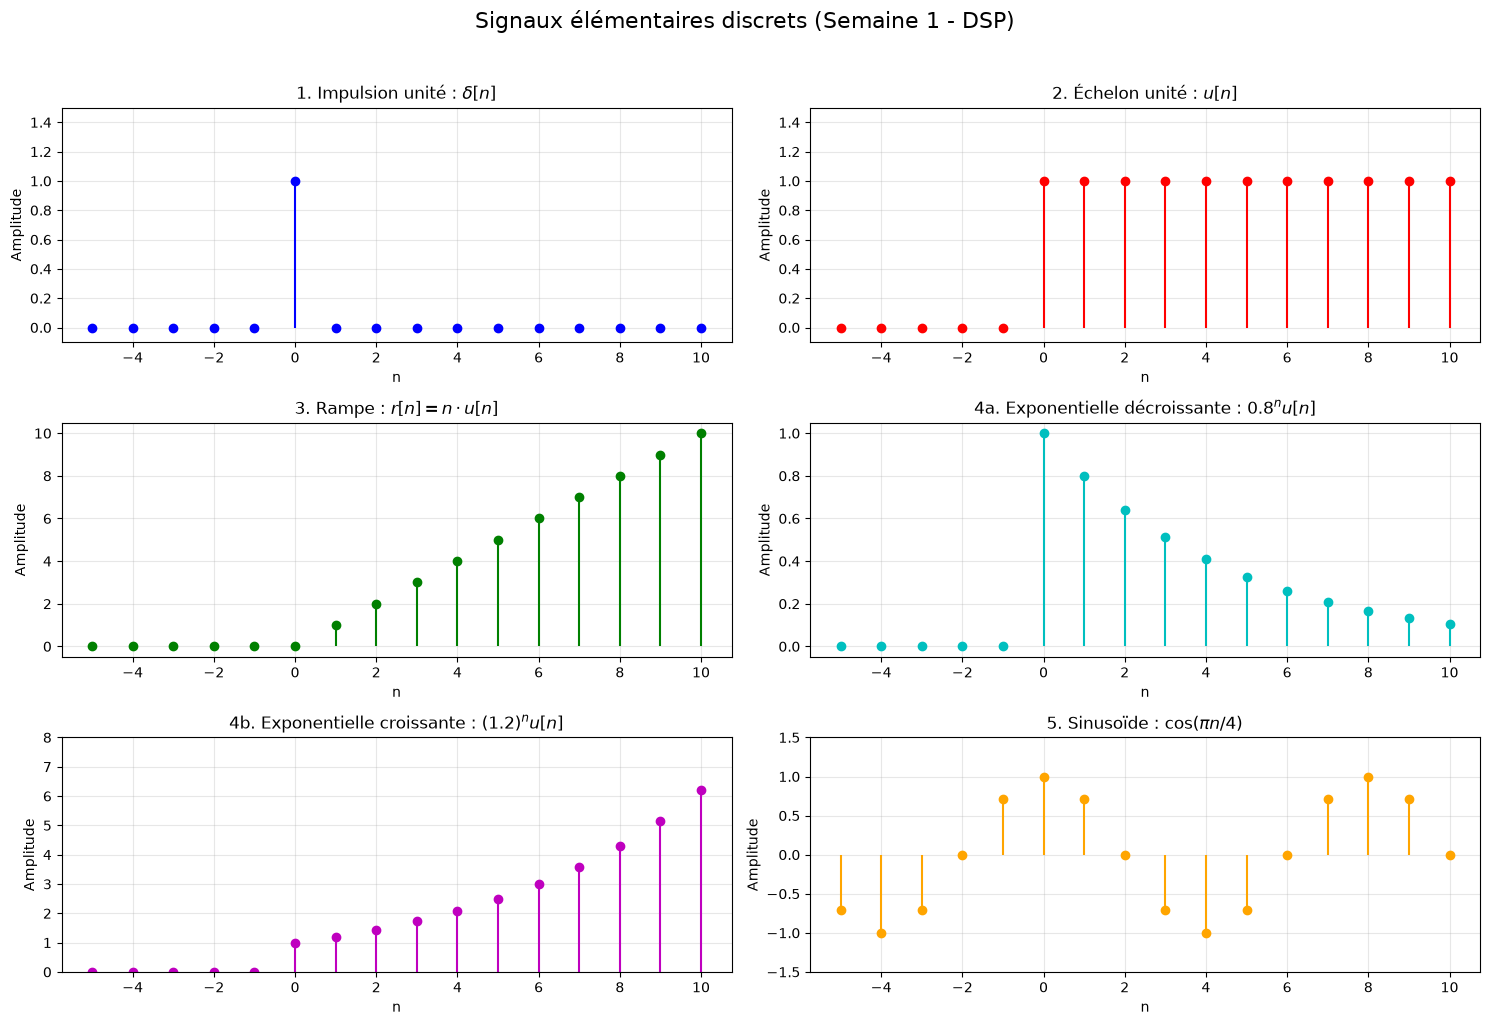

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Définition de l'axe temporel discret (de -5 à +10)
n = np.arange(-5, 11)

# --------------------------------------------------
# 1. Impulsion unité δ[n]
# --------------------------------------------------
delta = np.zeros_like(n, dtype=int)
delta[n == 0] = 1  # δ[0] = 1, sinon 0

# --------------------------------------------------
# 2. Échelon unité u[n]
# --------------------------------------------------
step = np.zeros_like(n, dtype=int)
step[n >= 0] = 1   # u[n] = 1 pour n >= 0

# --------------------------------------------------
# 3. Rampe r[n] = n * u[n]
# --------------------------------------------------
ramp = n * step    # Multiplication terme à terme

# --------------------------------------------------
# 4. Exponentielle réelle (décroissante et croissante)
#    x[n] = a^n u[n]
# --------------------------------------------------
a_decay = 0.8
a_grow = 1.2
exp_decay = (a_decay ** n) * step
exp_grow = (a_grow ** n) * step

# --------------------------------------------------
# 5. Sinusoïde : x[n] = cos(ω₀ n) avec ω₀ = π/4
# --------------------------------------------------
omega_0 = np.pi / 4
sinusoid = np.cos(omega_0 * n)

# --------------------------------------------------
# Affichage des graphiques (subplots)
# --------------------------------------------------
plt.figure(figsize=(15, 10))

# Graphique 1 : Impulsion
plt.subplot(3, 2, 1)
plt.stem(n, delta, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.title('1. Impulsion unité : $\\delta[n]$')
plt.xlabel('n'); plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.5)

# Graphique 2 : Échelon
plt.subplot(3, 2, 2)
plt.stem(n, step, basefmt=" ", linefmt='r-', markerfmt='ro')
plt.title('2. Échelon unité : $u[n]$')
plt.xlabel('n'); plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.5)

# Graphique 3 : Rampe
plt.subplot(3, 2, 3)
plt.stem(n, ramp, basefmt=" ", linefmt='g-', markerfmt='go')
plt.title('3. Rampe : $r[n] = n \\cdot u[n]$')
plt.xlabel('n'); plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# Graphique 4 : Exponentielle décroissante (a=0.8)
plt.subplot(3, 2, 4)
plt.stem(n, exp_decay, basefmt=" ", linefmt='c-', markerfmt='co')
plt.title('4a. Exponentielle décroissante : $0.8^n u[n]$')
plt.xlabel('n'); plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# Graphique 5 : Exponentielle croissante (a=1.2)
plt.subplot(3, 2, 5)
plt.stem(n, exp_grow, basefmt=" ", linefmt='m-', markerfmt='mo')
plt.title('4b. Exponentielle croissante : $(1.2)^n u[n]$')
plt.xlabel('n'); plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.ylim(0, 8)  # Pour mieux voir la croissance

# Graphique 6 : Sinusoïde
plt.subplot(3, 2, 6)
markerline, stemlines, baseline = plt.stem(	n, sinusoid, basefmt=" ", linefmt='-', markerfmt='o')
plt.setp(markerline, color='orange')
plt.setp(stemlines, color='orange')
plt.title('5. Sinusoïde : $\\cos(\\pi n / 4)$')
plt.xlabel('n'); plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)

plt.suptitle('Signaux élémentaires discrets (Semaine 1 - DSP)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## L'exponentielle complexe : le signal fondamental du DSP

L'exponentielle complexe est le signal le plus important du Traitement Numérique du Signal (DSP). Elle constitue la brique de base de la transformée de Fourier et de l'analyse spectrale. Elle est définie par la **formule d'Euler** :

$$x[n] = e^{j\omega_0 n} = \cos(\omega_0 n) + j \sin(\omega_0 n)$$

### Objectifs de la démonstration

1. **Représentation temporelle** : Afficher les parties réelle (cosinus) et imaginaire (sinus) séparément dans le domaine temporel, afin de visualiser le déphasage naturel de $90^\circ$ (quadrature) entre les deux composantes.

2. **Visualisation dans le plan complexe** : Tracer le **cercle unité** dans le plan complexe (axe des réels en abscisse, axe des imaginaires en ordonnée) pour montrer que le signal "tourne" autour du cercle à mesure que l'indice $n$ augmente. 

> ⚠️ **Astuce** : Ce deuxième graphique est **interessant**. Il démontre visuellement que $|e^{j\omega_0 n}| = 1$ (le signal ne grandit ni ne diminue) et que la phase augmente linéairement avec $n$. C'est la visualisation parfaite du concept de **phaseur** en temps discret.

### Propriétés fondamentales à retenir

- **Périodicité** : Le signal est périodique si $\omega_0 = 2\pi / N$, avec $N$ entier. Sa période fondamentale est $N = 2\pi / \omega_0$.
- **Indistinguabilité des fréquences** : Les fréquences $\omega_0$ et $\omega_0 + 2\pi$ produisent exactement le même signal, car $e^{j2\pi n} = 1$ pour tout entier $n$. C'est la raison pour laquelle le spectre d'un signal discret est **périodique de période $2\pi$**.
- **Application future** : Ce signal est une fonction propre des systèmes linéaires invariants dans le temps (SLIT). Si vous injectez $e^{j\omega_0 n}$ dans un filtre, il en ressort multiplié par un nombre complexe (la réponse en fréquence du système).

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


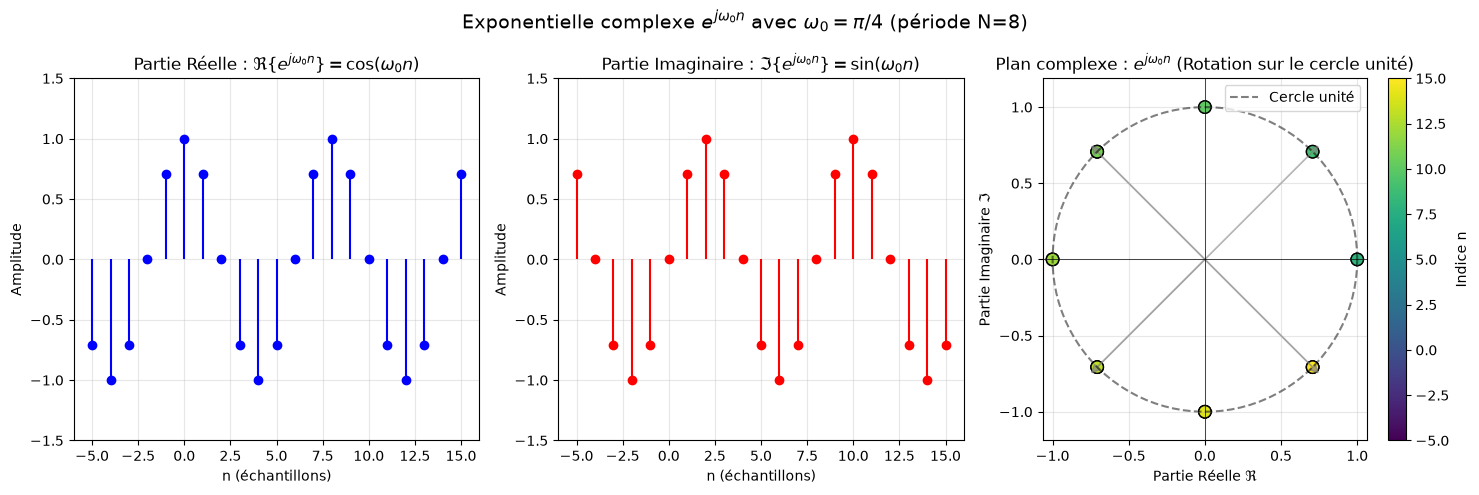

PROPRIÉTÉS FONDAMENTALES DE L'EXPONENTIELLE COMPLEXE
1. Périodicité : La période fondamentale est N = 2π/ω₀ = 8 échantillons.
   (On vérifie que x[n+N] = x[n])
2. Module : |e^(jω₀n)| = 1.0 (toujours 1)
3. Phase : ∠e^(jω₀n) = ω₀n (linéaire)
4. Fréquence ω₀ = 0.785 rad/échantillon
5. Indistinguabilité : e^(j(ω₀ + 2π)n) = e^(jω₀n) -> raies spectrales répétées tous les 2π.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Axe temporel discret
n = np.arange(-5, 16)  # de -5 à 15

# Paramètre : fréquence numérique (radians par échantillon)
omega_0 = np.pi / 4  # 45 degrés

# --------------------------------------------------
# 1. Génération de l'exponentielle complexe
#    x[n] = e^(j * omega_0 * n)
# --------------------------------------------------
x_complex = np.exp(1j * omega_0 * n)  # 1j est l'unité imaginaire en Python

# Extraction des parties réelle et imaginaire (formule d'Euler)
real_part = np.real(x_complex)  # cos(omega_0 * n)
imag_part = np.imag(x_complex)  # sin(omega_0 * n)

# --------------------------------------------------
# 2. Affichage : Parties réelle et imaginaire dans le temps
# --------------------------------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.stem(n, real_part, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.title('Partie Réelle : $\\Re\\{e^{j\\omega_0 n}\\} = \\cos(\\omega_0 n)$')
plt.xlabel('n (échantillons)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)

plt.subplot(1, 3, 2)
plt.stem(n, imag_part, basefmt=" ", linefmt='r-', markerfmt='ro')
plt.title('Partie Imaginaire : $\\Im\\{e^{j\\omega_0 n}\\} = \\sin(\\omega_0 n)$')
plt.xlabel('n (échantillons)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)

# --------------------------------------------------
# 3. Plan complexe (CERCLE UNITÉ) : Visualisation magistrale
#    On trace les points (Partie Réelle, Partie Imaginaire)
# --------------------------------------------------
plt.subplot(1, 3, 3)
# Tracé du cercle unité théorique (continu) pour référence
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5, label='Cercle unité')

# Tracé des points de l'exponentielle complexe
plt.scatter(real_part, imag_part, c=n, cmap='viridis', s=80, edgecolors='k')
# Ajout d'une flèche pour montrer le sens de rotation (optionnel)
for i in range(len(n)):
    if i % 2 == 0:  # On ne met pas de flèche partout pour éviter la surcharge
        plt.arrow(0, 0, real_part[i], imag_part[i], 
                  head_width=0.05, head_length=0.05, fc='gray', ec='gray', alpha=0.3)

plt.title('Plan complexe : $e^{j\\omega_0 n}$ (Rotation sur le cercle unité)')
plt.xlabel('Partie Réelle $\\Re$')
plt.ylabel('Partie Imaginaire $\\Im$')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Important pour que le cercle ne soit pas écrasé !
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.colorbar(label='Indice n')
plt.legend()

plt.suptitle(f'Exponentielle complexe $e^{{j \\omega_0 n}}$ avec $\\omega_0 = \\pi/4$ (période N=8)', fontsize=14)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4. Affichage des propriétés mathématiques clés
# --------------------------------------------------
print("="*50)
print("PROPRIÉTÉS FONDAMENTALES DE L'EXPONENTIELLE COMPLEXE")
print("="*50)
print(f"1. Périodicité : La période fondamentale est N = 2π/ω₀ = {2*np.pi/omega_0:.0f} échantillons.")
print(f"   (On vérifie que x[n+N] = x[n])")
print(f"2. Module : |e^(jω₀n)| = {np.abs(x_complex[0]):.1f} (toujours 1)")
print(f"3. Phase : ∠e^(jω₀n) = ω₀n (linéaire)")
print(f"4. Fréquence ω₀ = {omega_0:.3f} rad/échantillon")
print(f"5. Indistinguabilité : e^(j(ω₀ + 2π)n) = e^(jω₀n) -> raies spectrales répétées tous les 2π.")

# 6. Synthèse et Q&A


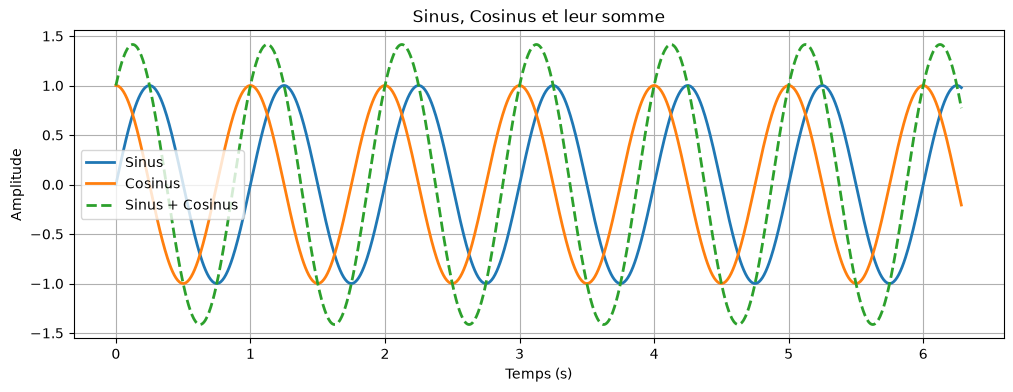

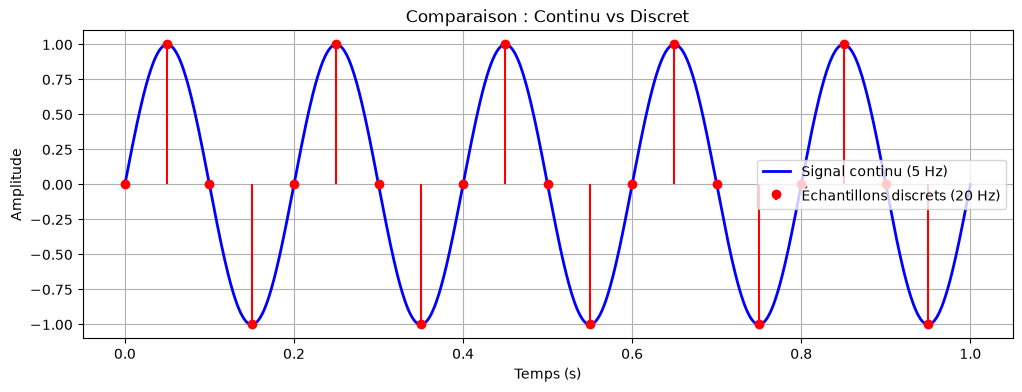

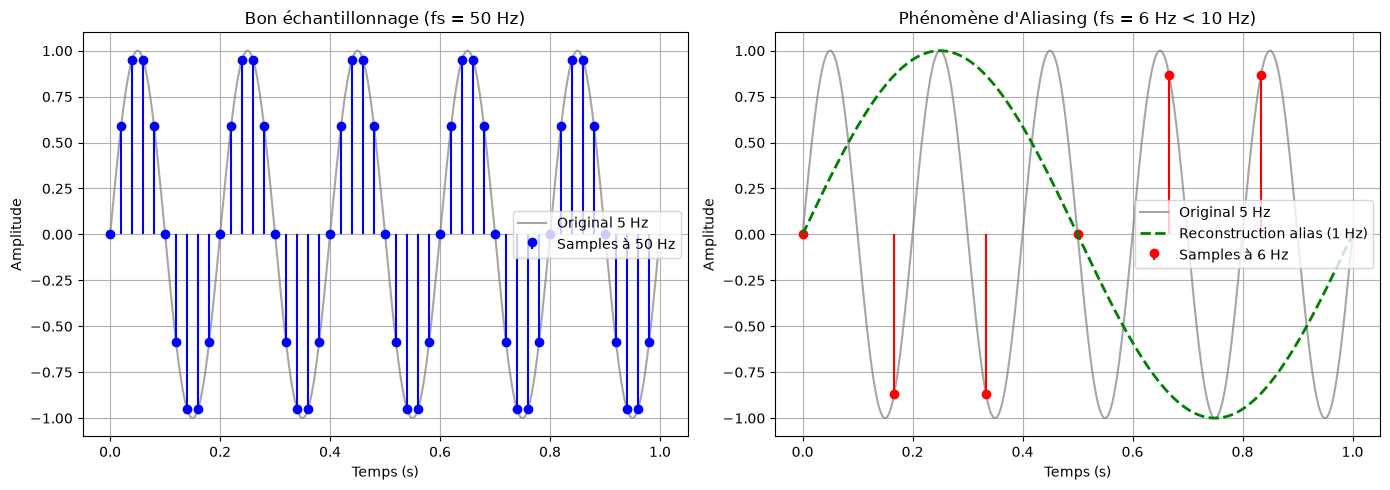

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Affichage d'un sinus, d'un cosinus et de leur somme
# ------------------------------------------------------------
t = np.linspace(0, 2 * np.pi, 1000)
f = 1  # 1 Hz

sine = np.sin(2 * np.pi * f * t)
cosine = np.cos(2 * np.pi * f * t)
sum_signal = sine + cosine

plt.figure(figsize=(12, 4))
plt.plot(t, sine, label='Sinus', linewidth=2)
plt.plot(t, cosine, label='Cosinus', linewidth=2)
plt.plot(t, sum_signal, label='Sinus + Cosinus', linestyle='--', linewidth=2)
plt.title('Sinus, Cosinus et leur somme')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 2. Représentation continu vs discret (Échantillonnage)
# ------------------------------------------------------------
t_cont = np.linspace(0, 1, 1000)
f_signal = 5  # Signal à 5 Hz
x_cont = np.sin(2 * np.pi * f_signal * t_cont)

fs = 20  # Fréquence d'échantillonnage (4 échantillons par période)
t_disc = np.arange(0, 1, 1/fs)
x_disc = np.sin(2 * np.pi * f_signal * t_disc)

plt.figure(figsize=(12, 4))
plt.plot(t_cont, x_cont, label='Signal continu (5 Hz)', linewidth=2, color='blue')
plt.stem(t_disc, x_disc, linefmt='r-', markerfmt='ro', basefmt=' ', label='Échantillons discrets (20 Hz)')
plt.title('Comparaison : Continu vs Discret')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 3. Illustration du repliement de spectre (Aliasing)
# ------------------------------------------------------------
f_signal = 5  # 5 Hz

# Signal original (continu)
t_cont = np.linspace(0, 1, 1000)
x_cont = np.sin(2 * np.pi * f_signal * t_cont)

# Échantillonnage correct : fs = 50 Hz (> 2*5Hz)
fs_proper = 50
t_proper = np.arange(0, 1, 1/fs_proper)
x_proper = np.sin(2 * np.pi * f_signal * t_proper)

# Sous-échantillonnage (Aliasing) : fs = 6 Hz (< 2*5Hz)
fs_aliased = 6
t_aliased = np.arange(0, 1, 1/fs_aliased)
x_aliased = np.sin(2 * np.pi * f_signal * t_aliased)
# Le signal reconstitué (alias) apparaît à |6 - 5| = 1 Hz
t_alias_recon = np.linspace(0, 1, 1000)
x_alias_recon = np.sin(2 * np.pi * (fs_aliased - f_signal) * t_alias_recon)

plt.figure(figsize=(14, 5))

# Sous-plot gauche : Bon échantillonnage
plt.subplot(1, 2, 1)
plt.plot(t_cont, x_cont, label='Original 5 Hz', color='gray', alpha=0.7)
plt.stem(t_proper, x_proper, linefmt='b-', markerfmt='bo', basefmt=' ', label='Samples à 50 Hz')
plt.title('Bon échantillonnage (fs = 50 Hz)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

# Sous-plot droite : Aliasing
plt.subplot(1, 2, 2)
plt.plot(t_cont, x_cont, label='Original 5 Hz', color='gray', alpha=0.7)
plt.stem(t_aliased, x_aliased, linefmt='r-', markerfmt='ro', basefmt=' ', label='Samples à 6 Hz')
plt.plot(t_alias_recon, x_alias_recon, 'g--', linewidth=2, label='Reconstruction alias (1 Hz)')
plt.title('Phénomène d\'Aliasing (fs = 6 Hz < 10 Hz)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Activités des étudiants (Devoir / TP noté)
# Partie 1 – Classification de signaux (40 % du devoir)

Pour chacun des signaux suivants, indiquez s'il est :

- **Temps continu ou Temps discret ?**
- **Analogique ou Numérique (amplitude) ?**
- **Périodique ou Apériodique ?** (si périodique, donner la période)
- **Causal ou Non-causal ?**
- **Pair, Impair ou Ni l'un ni l'autre ?**
- **Signal à énergie ou Signal à puissance** (justifier par le calcul si possible) ?

---

## Signal 1

$$ x(t) = \cos(2\pi \times 1000t) + \cos(2\pi \times 2000t) $$

---

## Signal 2

$$
x[n] = (0.5)^n \, u[n]
$$ 

où $u[n]$ est l'échelon unité discret.

---


## Signal 3

$$ x(t) = e^{-2|t|} $$

---

## Signal 4

$$ x[n] = \sin\left(\frac{\pi n}{4}\right) + \sin\left(\frac{\pi n}{2}\right) $$

---

## Signal 5

$$ x(t) = \begin{cases} t^2, & t \geq 0 \\ 0, & \text{ailleurs} \end{cases} $$

---

## Partie 2 – Recherche d'application (30 %)

Choisissez **une** application DSP parmi la liste suivante et rédigez un rapport d'1 à 2 pages présentant :

1. Le problème physique résolu.
2. La nature du signal traité.
3. Les blocs DSP typiquement utilisés (filtrage, FFT, modulation, etc.).
4. Pourquoi le numérique est préféré à l'analogique dans ce cas précis.

### Liste des applications :

| # | Application DSP | Domaine d'application |
| :-: | :--- | :--- |
| 1 | **Casque anti-bruit actif** | Audio / Acoustique |
| 2 | **Surveillance cardiaque (ECG) embarquée** | Biomédical / Santé |
| 3 | **Compression audio (MP3 / AAC)** | Audio / Multimédia |
| 4 | **Système de radar de recul automobile** | Automobile / Détection |
| 5 | **Reconnaissance vocale (assistant vocal)** | Intelligence artificielle / IoT |
| 6 | **Commande de moteurs électriques (Control Moteur)** | Automobile / Industrie / Robotique |

---

## Partie 3 – Schéma bloc (30 %)

Dans cette partie, nous nous concentrons sur un **pédalier d'effet audio numérique**, un classique du TNS embarqué utilisé par les musiciens (guitaristes, claviéristes). L'objectif est de transformer le signal d'un instrument en lui ajoutant des échos ou une spatialisation sonore.

Pour vous guider, voici un rappel des deux effets possibles :

- **L'effet Delay (écho)** : Il consiste à mémoriser temporairement le signal d'entrée pour le rejouer avec un léger retard (généralement entre 20 ms et 1 s). L'équation simplifiée est :  
  $$
  y[n] = x[n] + \alpha \cdot x[n - D]
  $$  
  où \( D \) est le retard en échantillons et \( \alpha \) le facteur d'atténuation (pour simuler la perte d'énergie). On entend alors le son original suivi d'une ou plusieurs répétitions.

- **L'effet Réverbération (Reverb)** : Il simule la persistance du son dans une salle (multiples réflexions sur les murs, le plafond, etc.). Contrairement au Delay simple, la réverbération utilise un réseau de **filtres en peigne (comb filters)** et de **filtres passe-tout (all-pass)** en cascade, créant une densité d'échos très élevée pour imiter l'acoustique d'un espace (petite pièce, cathédrale, etc.).

---

### 📝 Consigne détaillée

Choisissez l'un de ces deux effets (Delay ou Réverbération) et réalisez les étapes suivantes :

1. **Dessinez** la chaîne de traitement complète sous forme de schéma-bloc fonctionnel.
2. **Expliquez** le rôle de chaque bloc dans le contexte de votre effet choisi.

Votre schéma devra impérativement identifier les blocs suivants dans l'ordre chronologique du traitement :

> **Entrée audio (instrument)** → **Filtre anti-alias** → **Convertisseur ADC** → **Processeur numérique (algorithme)** → **Convertisseur DAC** → **Filtre de reconstruction** → **Sortie audio (amplificateur)**

---